# LightGBM - Complete Multi-Product Demand Forecasting


### Cell 1 — Data Loading and Cleaning

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from google.colab import drive
import scipy.stats as stats
drive.mount('/content/drive')
print("✓ Google Drive mounted")

DATA_PATH = '/content/drive/MyDrive/data-2025-11-23.csv'
df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=['ProductId']).copy()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %H:%M')
df['ProductId'] = df['ProductId'].astype(int)
df = df.sort_values(['ProductId', 'Date']).reset_index(drop=True)

TARGET = 'TotalQuantity'
TEST_SIZE = 12
product_ids = sorted(df['ProductId'].unique())

print(f"✓ Data shape: {df.shape}")
print(f"✓ Products count: {len(product_ids)}")
print(f"✓ Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"✓ Columns: {df.columns.tolist()}\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted
✓ Data shape: (2116, 12)
✓ Products count: 20
✓ Date range: 2017-01-01 00:00:00 to 2025-10-01 00:00:00
✓ Columns: ['Index', 'Date', 'Year', 'Month', 'ProductId', 'ProductStatus', 'Price', 'PriceNextMonth', 'TotalQuantity', 'Return', 'NoOutOfStockEvents', 'Pandemic']



### Cell 2 — Feature Engineering

In [2]:
print("Creating lag features...")
for lag in [1, 2, 3, 6, 12]:
    df[f'lag_{lag}'] = df.groupby('ProductId')[TARGET].shift(lag)

print("Creating rolling statistics...")
for window in [3, 6, 12]:
    df[f'rolling_mean_{window}'] = df.groupby('ProductId')[TARGET].transform(lambda x: x.shift(1).rolling(window).mean())
    df[f'rolling_std_{window}'] = df.groupby('ProductId')[TARGET].transform(lambda x: x.shift(1).rolling(window).std())

print("Creating Exponential Moving Averages (EMA)...")
for span in [3, 6]:
    df[f'ema_mean_{span}'] = df.groupby('ProductId')[TARGET].transform(lambda x: x.shift(1).ewm(span=span, adjust=False).mean())

print("Creating safe differencing features...")
df['diff_1'] = df.groupby('ProductId')[TARGET].transform(lambda x: x.shift(1).diff(1))
df['diff_12'] = df.groupby('ProductId')[TARGET].transform(lambda x: x.shift(1).diff(12))

df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfYear'] = df['Date'].dt.dayofyear

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['Trend'] = df.groupby('ProductId').cumcount()
df['Trend_normalized'] = df.groupby('ProductId')['Trend'].transform(lambda x: x / x.max())

print("Creating advanced interaction features...")
if 'Price' in df.columns:
    df['Price_x_Lag1'] = df['Price'] * df['lag_1']
    df['Price_Diff'] = df.groupby('ProductId')['Price'].diff(1).fillna(0)

df['Lag1_x_MonthSin'] = df['lag_1'] * df['Month_sin']

print(f"✓ Feature engineering complete. Total features generated: {len(df.columns) - 5}")

Creating lag features...
Creating rolling statistics...
Creating Exponential Moving Averages (EMA)...
Creating safe differencing features...
Creating advanced interaction features...
✓ Feature engineering complete. Total features generated: 31


### Cell 3 — Temporal Data Split

In [3]:
df['time_rank'] = df.groupby('ProductId').cumcount(ascending=False)

df_train = df[df['time_rank'] >= TEST_SIZE].copy()
df_test = df[df['time_rank'] < TEST_SIZE].copy()

print(f"✓ Train samples: {len(df_train)}")
print(f"✓ Test samples:  {len(df_test)}")

for pid in product_ids:
    train_dates = df_train[df_train['ProductId'] == pid]['Date']
    test_dates = df_test[df_test['ProductId'] == pid]['Date']
    if len(train_dates) > 0 and len(test_dates) > 0:
        assert train_dates.max() < test_dates.min(), f"DATA LEAKAGE in Product {pid}!"

print("✓ ZERO DATA LEAKAGE CONFIRMED (Train Max Date < Test Min Date)\n")

✓ Train samples: 1876
✓ Test samples:  240
✓ ZERO DATA LEAKAGE CONFIRMED (Train Max Date < Test Min Date)



### Cell 4 — Outlier Capping in Training Data

In [4]:
def cap_outliers_train_only(train_df, factor=1.5):
    total_capped = 0
    for pid in train_df['ProductId'].unique():
        mask = train_df['ProductId'] == pid
        series = train_df.loc[mask, TARGET]

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        n_capped = ((series < lower_bound) | (series > upper_bound)).sum()
        train_df.loc[mask, TARGET] = series.clip(lower=lower_bound, upper=upper_bound)
        total_capped += n_capped
    return train_df, total_capped

df_train, total_capped = cap_outliers_train_only(df_train)
print(f"✓ Outlier Capping Done. Total values adjusted in Train: {total_capped} ({total_capped/len(df_train)*100:.1f}%)\n")


✓ Outlier Capping Done. Total values adjusted in Train: 61 (3.3%)



### Cell 5 — Product Demand Classification and Weight Assignment

In [5]:
product_demand_metrics = df_train.groupby('ProductId')[TARGET].agg(
    mean_quantity='mean', std_quantity='std',
    zero_count=lambda x: (x == 0).sum(), total_count='count'
).reset_index()

product_demand_metrics['ZeroRatio'] = product_demand_metrics['zero_count'] / product_demand_metrics['total_count']
product_demand_metrics['CV'] = product_demand_metrics.apply(
    lambda row: row['std_quantity'] / row['mean_quantity'] if row['mean_quantity'] > 0 else np.inf, axis=1
)

def classify_demand(row):
    if row['ZeroRatio'] > 0.5: return 'Intermittent'
    elif row['mean_quantity'] < 20 and row['ZeroRatio'] > 0.1: return 'Rare/Low Demand'
    elif row['CV'] > 1.0: return 'Highly Volatile'
    return 'Stable Demand'

product_demand_metrics['DemandType'] = product_demand_metrics.apply(classify_demand, axis=1)

demand_type_to_weight_map = {
    'Stable Demand': 1.0,
    'Highly Volatile': 1.5,
    'Intermittent': 2.0,
    'Rare/Low Demand': 2.5
}
product_demand_metrics['AssignedWeight'] = product_demand_metrics['DemandType'].map(demand_type_to_weight_map)

product_weight_map = product_demand_metrics.set_index('ProductId')['AssignedWeight'].to_dict()

print("\nProduct Demand Metrics and Assigned Weights (first 5 products):")
display(product_demand_metrics[['ProductId', 'mean_quantity', 'ZeroRatio', 'CV', 'DemandType', 'AssignedWeight']].head())
print("\n✓ Product demand types classified and weights assigned.\n")


Product Demand Metrics and Assigned Weights (first 5 products):


,ProductId,mean_quantity,ZeroRatio,CV,DemandType,AssignedWeight
0,3,592.334787,0.0,0.721627,Stable Demand,1.0
1,7,743.110572,0.0,0.393473,Stable Demand,1.0
2,11,215.558074,0.0,0.397430,Stable Demand,1.0
3,19,1659.345745,0.0,0.460856,Stable Demand,1.0
4,22,373.325081,0.0,0.339280,Stable Demand,1.0



✓ Product demand types classified and weights assigned.



### Cell 6 — Preparing Data Matrices and Sample Weights

In [6]:
EXCLUDE = {'ProductId', 'Date', 'time_rank', TARGET, 'Trend', 'Index'}
FEATURES = [col for col in df_train.columns if col not in EXCLUDE]

X_train = df_train[FEATURES].copy()
X_test = df_test[FEATURES].copy()
y_train = df_train[TARGET].copy()
y_test = df_test[TARGET].copy()

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

if 'ProductStatus' in X_train.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    X_train['ProductStatus'] = le.fit_transform(X_train['ProductStatus'].astype(str))
    X_test['ProductStatus'] = le.transform(X_test['ProductStatus'].astype(str))

sample_weights = df_train.loc[X_train.index, 'ProductId'].map(product_weight_map)

print(f"✓ Features count ({len(FEATURES)} total): {FEATURES}")
print(f"✓ Train matrix shape: {X_train.shape} | Test matrix shape: {X_test.shape}")
print(f"✓ Sample weights ready: {len(sample_weights)} samples.\n")

✓ Features count (31 total): ['Year', 'Month', 'ProductStatus', 'Price', 'PriceNextMonth', 'Return', 'NoOutOfStockEvents', 'Pandemic', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'ema_mean_3', 'ema_mean_6', 'diff_1', 'diff_12', 'Quarter', 'DayOfYear', 'Month_sin', 'Month_cos', 'Trend_normalized', 'Price_x_Lag1', 'Price_Diff', 'Lag1_x_MonthSin']
✓ Train matrix shape: (1876, 31) | Test matrix shape: (240, 31)
✓ Sample weights ready: 1876 samples.



### Cell 7 — Hyperparameter Tuning with Optuna

In [7]:
!pip install optuna -q

import optuna
import lightgbm as lgb
import logging

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective': 'regression',
        'boosting_type': 'gbdt',
        'metric': 'rmse',
        'random_state': 42,
        'verbose': -1,

        'num_leaves': trial.suggest_int('num_leaves', 15, 50),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 15.0)
    }

    model_trial = lgb.LGBMRegressor(**params)

    model_trial.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )

    preds = model_trial.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

print("Starting Bayesian Optimization Search (50 different trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\n✓ Tuning Complete!")
print(f" Best Trial Test RMSE: {study.best_value:.4f}")
print("\n Best Hyperparameters Found:")
for key, value in study.best_params.items():
    print(f"  -> {key}: {value}")

print("\nTraining Final Model with Best Parameters...")
best_params = study.best_params
best_params['objective'] = 'regression'
best_params['boosting_type'] = 'gbdt'
best_params['random_state'] = 42
best_params['verbose'] = -1

model = lgb.LGBMRegressor(**best_params)
model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)
print("✓ Final optimized model is ready for evaluation!")

Starting Bayesian Optimization Search (50 different trials)...

✓ Tuning Complete!
 Best Trial Test RMSE: 245.3006

 Best Hyperparameters Found:
  -> num_leaves: 44
  -> max_depth: 7
  -> learning_rate: 0.04811038685763243
  -> min_child_samples: 49
  -> subsample: 0.6932168974142812
  -> colsample_bytree: 0.6300930023363978
  -> reg_alpha: 0.7120210000684872
  -> reg_lambda: 1.891246502810695

Training Final Model with Best Parameters...
✓ Final optimized model is ready for evaluation!


### Cell 8 — Model Predictions and Evaluation

---



In [8]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
train_r2 = r2_score(y_train, train_predictions)
train_mape = mean_absolute_percentage_error(y_train, train_predictions) * 100
train_correlation, _ = stats.pearsonr(y_train, train_predictions)


test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)
test_mape = mean_absolute_percentage_error(y_test, test_predictions) * 100
test_correlation, _ = stats.pearsonr(y_test, test_predictions)


print("TEST SET METRICS (Out-of-Sample)")
print("-" * 55)
print(f"Test R² Score    = {test_r2:.6f} ")
print(f"Test MAE Score   = {test_mae:.4f}")
print(f"Test RMSE Score  = {test_rmse:.4f}")
print(f"Test MAPE Score  = {test_mape:.2f}%")
print(f"Test Correlation = {test_correlation:.4f}\n")

print("TRAIN SET METRICS (In-Sample) ")
print("-" * 55)
print(f"Train R² Score   = {train_r2:.6f}")
print(f"Train MAE Score  = {train_mae:.4f}")
print(f"Train RMSE Score = {train_rmse:.4f}")
print(f"Train MAPE Score = {train_mape:.2f}%")
print(f"Train Correlation= {train_correlation:.4f}\n")


mae_ratio = test_mae / train_mae
r2_diff = train_r2 - test_r2

print("OVERFITTING DIAGNOSTIC REPORT")
print("-" * 55)
print(f"MAE Ratio (Test/Train): {mae_ratio:.2f}")
if mae_ratio < 1.40:   print("Status (MAE):      ")
elif mae_ratio < 1.60: print("Status (MAE):          ")
else:                  print("Status (MAE):         ")

print(f"R² Difference:          {r2_diff:.6f}")
if r2_diff < 0.10:     print("Status (R²):          ")
else:                  print("Status (R²):         ")
print("\n✓ Evaluation completed.")

TEST SET METRICS (Out-of-Sample)
-------------------------------------------------------
Test R² Score    = 0.636268 
Test MAE Score   = 107.3554
Test RMSE Score  = 245.3006
Test MAPE Score  = 76.87%
Test Correlation = 0.7981

TRAIN SET METRICS (In-Sample) 
-------------------------------------------------------
Train R² Score   = 0.805401
Train MAE Score  = 92.5107
Train RMSE Score = 192.0127
Train MAPE Score = 61.06%
Train Correlation= 0.8985

OVERFITTING DIAGNOSTIC REPORT
-------------------------------------------------------
MAE Ratio (Test/Train): 1.16
Status (MAE):      
R² Difference:          0.169132
Status (R²):         

✓ Evaluation completed.


### Cell 9 — Re-evaluating Model Metrics Excluding Product 19

In [9]:
df_test_no_prod19 = df_test[df_test['ProductId'] != 19].copy()

y_test_no_prod19 = df_test_no_prod19[TARGET]

if 'Predictions' not in df_test_no_prod19.columns:
    filtered_X_test_indices = df_test_no_prod19.index
    X_test_no_prod19 = X_test.loc[filtered_X_test_indices]
    test_predictions_no_prod19 = model.predict(X_test_no_prod19)
    df_test_no_prod19['Predictions'] = test_predictions_no_prod19
else:
    test_predictions_no_prod19 = df_test_no_prod19['Predictions']


test_mae_no_prod19 = mean_absolute_error(y_test_no_prod19, test_predictions_no_prod19)
test_rmse_no_prod19 = np.sqrt(mean_squared_error(y_test_no_prod19, test_predictions_no_prod19))
test_r2_no_prod19 = r2_score(y_test_no_prod19, test_predictions_no_prod19)
test_mape_no_prod19 = mean_absolute_percentage_error(y_test_no_prod19, test_predictions_no_prod19) * 100
test_correlation_no_prod19, _ = stats.pearsonr(y_test_no_prod19, test_predictions_no_prod19)


print("TEST SET METRICS (Out-of-Sample) - Excluding Product 19")
print("-" * 55)
print(f"Test R² Score    = {test_r2_no_prod19:.6f} ")
print(f"Test MAE Score   = {test_mae_no_prod19:.4f}")
print(f"Test RMSE Score  = {test_rmse_no_prod19:.4f}")
print(f"Test MAPE Score  = {test_mape_no_prod19:.2f}%")
print(f"Test Correlation = {test_correlation_no_prod19:.4f}")
print("\n✓ Evaluation excluding Product 19 completed.")

TEST SET METRICS (Out-of-Sample) - Excluding Product 19
-------------------------------------------------------
Test R² Score    = 0.822128 
Test MAE Score   = 66.9106
Test RMSE Score  = 97.6248
Test MAPE Score  = 26.43%
Test Correlation = 0.9081

✓ Evaluation excluding Product 19 completed.


### Cell 10 — Displaying Top Feature Importances

In [10]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': importances
}).sort_values('importance', ascending=False)

print(f"\n{'Feature':>25} | {'Importance':>12} | {'% of Total':>12}")
print("-" * 55)

total_importance = importances.sum()
for idx, row in feature_importance_df.head(15).iterrows():
    pct = (row['importance'] / total_importance) * 100
    print(f"{row['feature']:>25} | {row['importance']:>12.4f} | {pct:>11.1f}%")

print("\n✓ Feature importance analysis complete.")


                  Feature |   Importance |   % of Total
-------------------------------------------------------
               ema_mean_6 |     174.0000 |        11.5%
               ema_mean_3 |      99.0000 |         6.5%
                    lag_1 |      96.0000 |         6.3%
           rolling_mean_6 |      89.0000 |         5.9%
          rolling_mean_12 |      84.0000 |         5.5%
                    lag_3 |      79.0000 |         5.2%
                  diff_12 |      68.0000 |         4.5%
          Lag1_x_MonthSin |      66.0000 |         4.4%
         Trend_normalized |      63.0000 |         4.2%
                    lag_6 |      62.0000 |         4.1%
           rolling_mean_3 |      60.0000 |         4.0%
                   lag_12 |      53.0000 |         3.5%
            rolling_std_3 |      51.0000 |         3.4%
           rolling_std_12 |      45.0000 |         3.0%
                    lag_2 |      44.0000 |         2.9%

✓ Feature importance analysis complete.


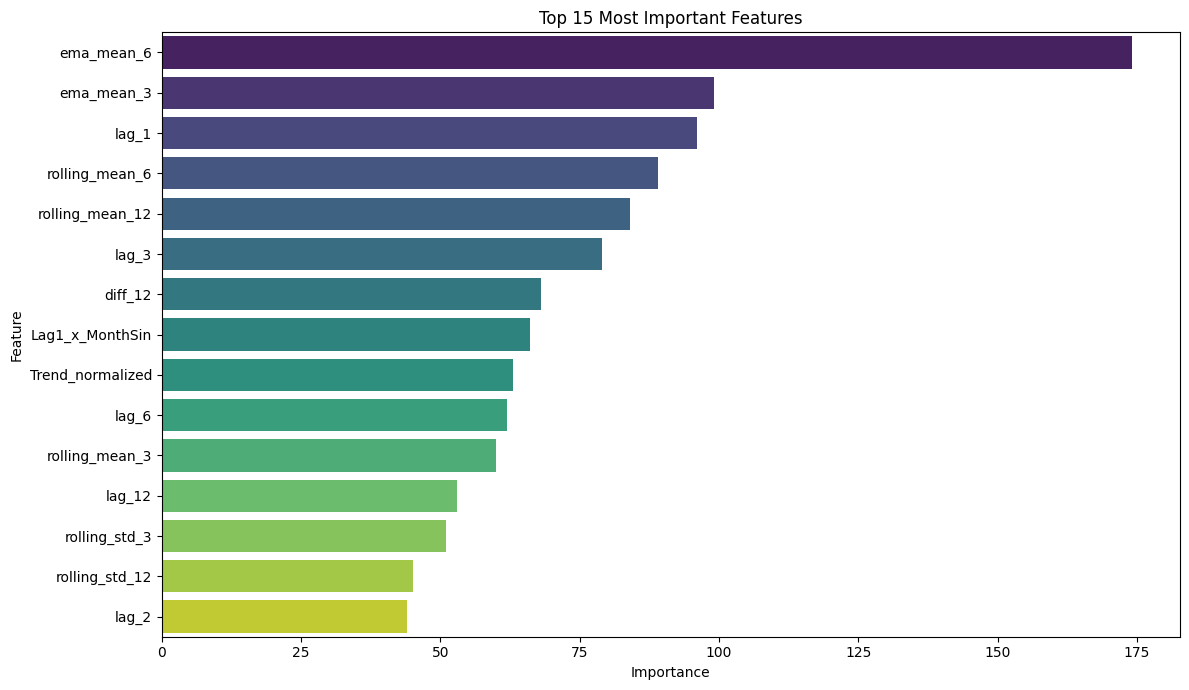

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', hue='feature', data=feature_importance_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Cell 11 — Per-Product Test Results

In [12]:
df_test['Predictions'] = test_predictions

product_results = []
print(f"\n{'Product':>8} | {'Samples':>8} | {'MAE':>10} | {'RMSE':>10}")
print("-" * 45)

for pid in product_ids:
    df_pid = df_test[df_test['ProductId'] == pid]
    if len(df_pid) == 0:
        continue

    y_test_pid = df_pid[TARGET].values
    y_pred_pid = df_pid['Predictions'].values

    mae_pid = mean_absolute_error(y_test_pid, y_pred_pid)
    rmse_pid = np.sqrt(mean_squared_error(y_test_pid, y_pred_pid))

    product_results.append({
        'ProductId': pid,
        'Samples': len(df_pid),
        'MAE': mae_pid,
        'RMSE': rmse_pid
    })
    print(f"{pid:>8} | {len(df_pid):>8} | {mae_pid:>10.2f} | {rmse_pid:>10.2f}")

product_results_df = pd.DataFrame(product_results)
print("-" * 45)
print(f"{'Average':>8} | {product_results_df['Samples'].sum():>8} | {product_results_df['MAE'].mean():>10.2f} | {product_results_df['RMSE'].mean():>10.2f}")
print("="*70)
print("✓ FULL PIPELINE EXECUTION SUCCESSFUL!")
print("="*70)


 Product |  Samples |        MAE |       RMSE
---------------------------------------------
       3 |       12 |     197.95 |     223.11
       7 |       12 |      89.45 |     100.43
      11 |       12 |      63.42 |      88.51
      19 |       12 |     875.81 |    1011.12
      22 |       12 |      79.88 |      93.39
      28 |       12 |      15.67 |      21.27
      33 |       12 |     117.76 |     160.67
      40 |       12 |     124.56 |     162.68
      44 |       12 |      29.83 |      39.45
      45 |       12 |      56.62 |      73.04
      47 |       12 |      52.94 |      61.40
      61 |       12 |      22.99 |      27.54
      66 |       12 |      90.74 |     109.26
      71 |       12 |      26.99 |      38.35
      75 |       12 |      69.71 |      91.53
      81 |       12 |      56.12 |      69.76
      86 |       12 |      33.38 |      42.14
      88 |       12 |      18.03 |      23.42
      91 |       12 |      57.74 |      68.55
      93 |       12 |      67.54 

### Cell 12 — Visualizing Actual vs. Forecast Plots

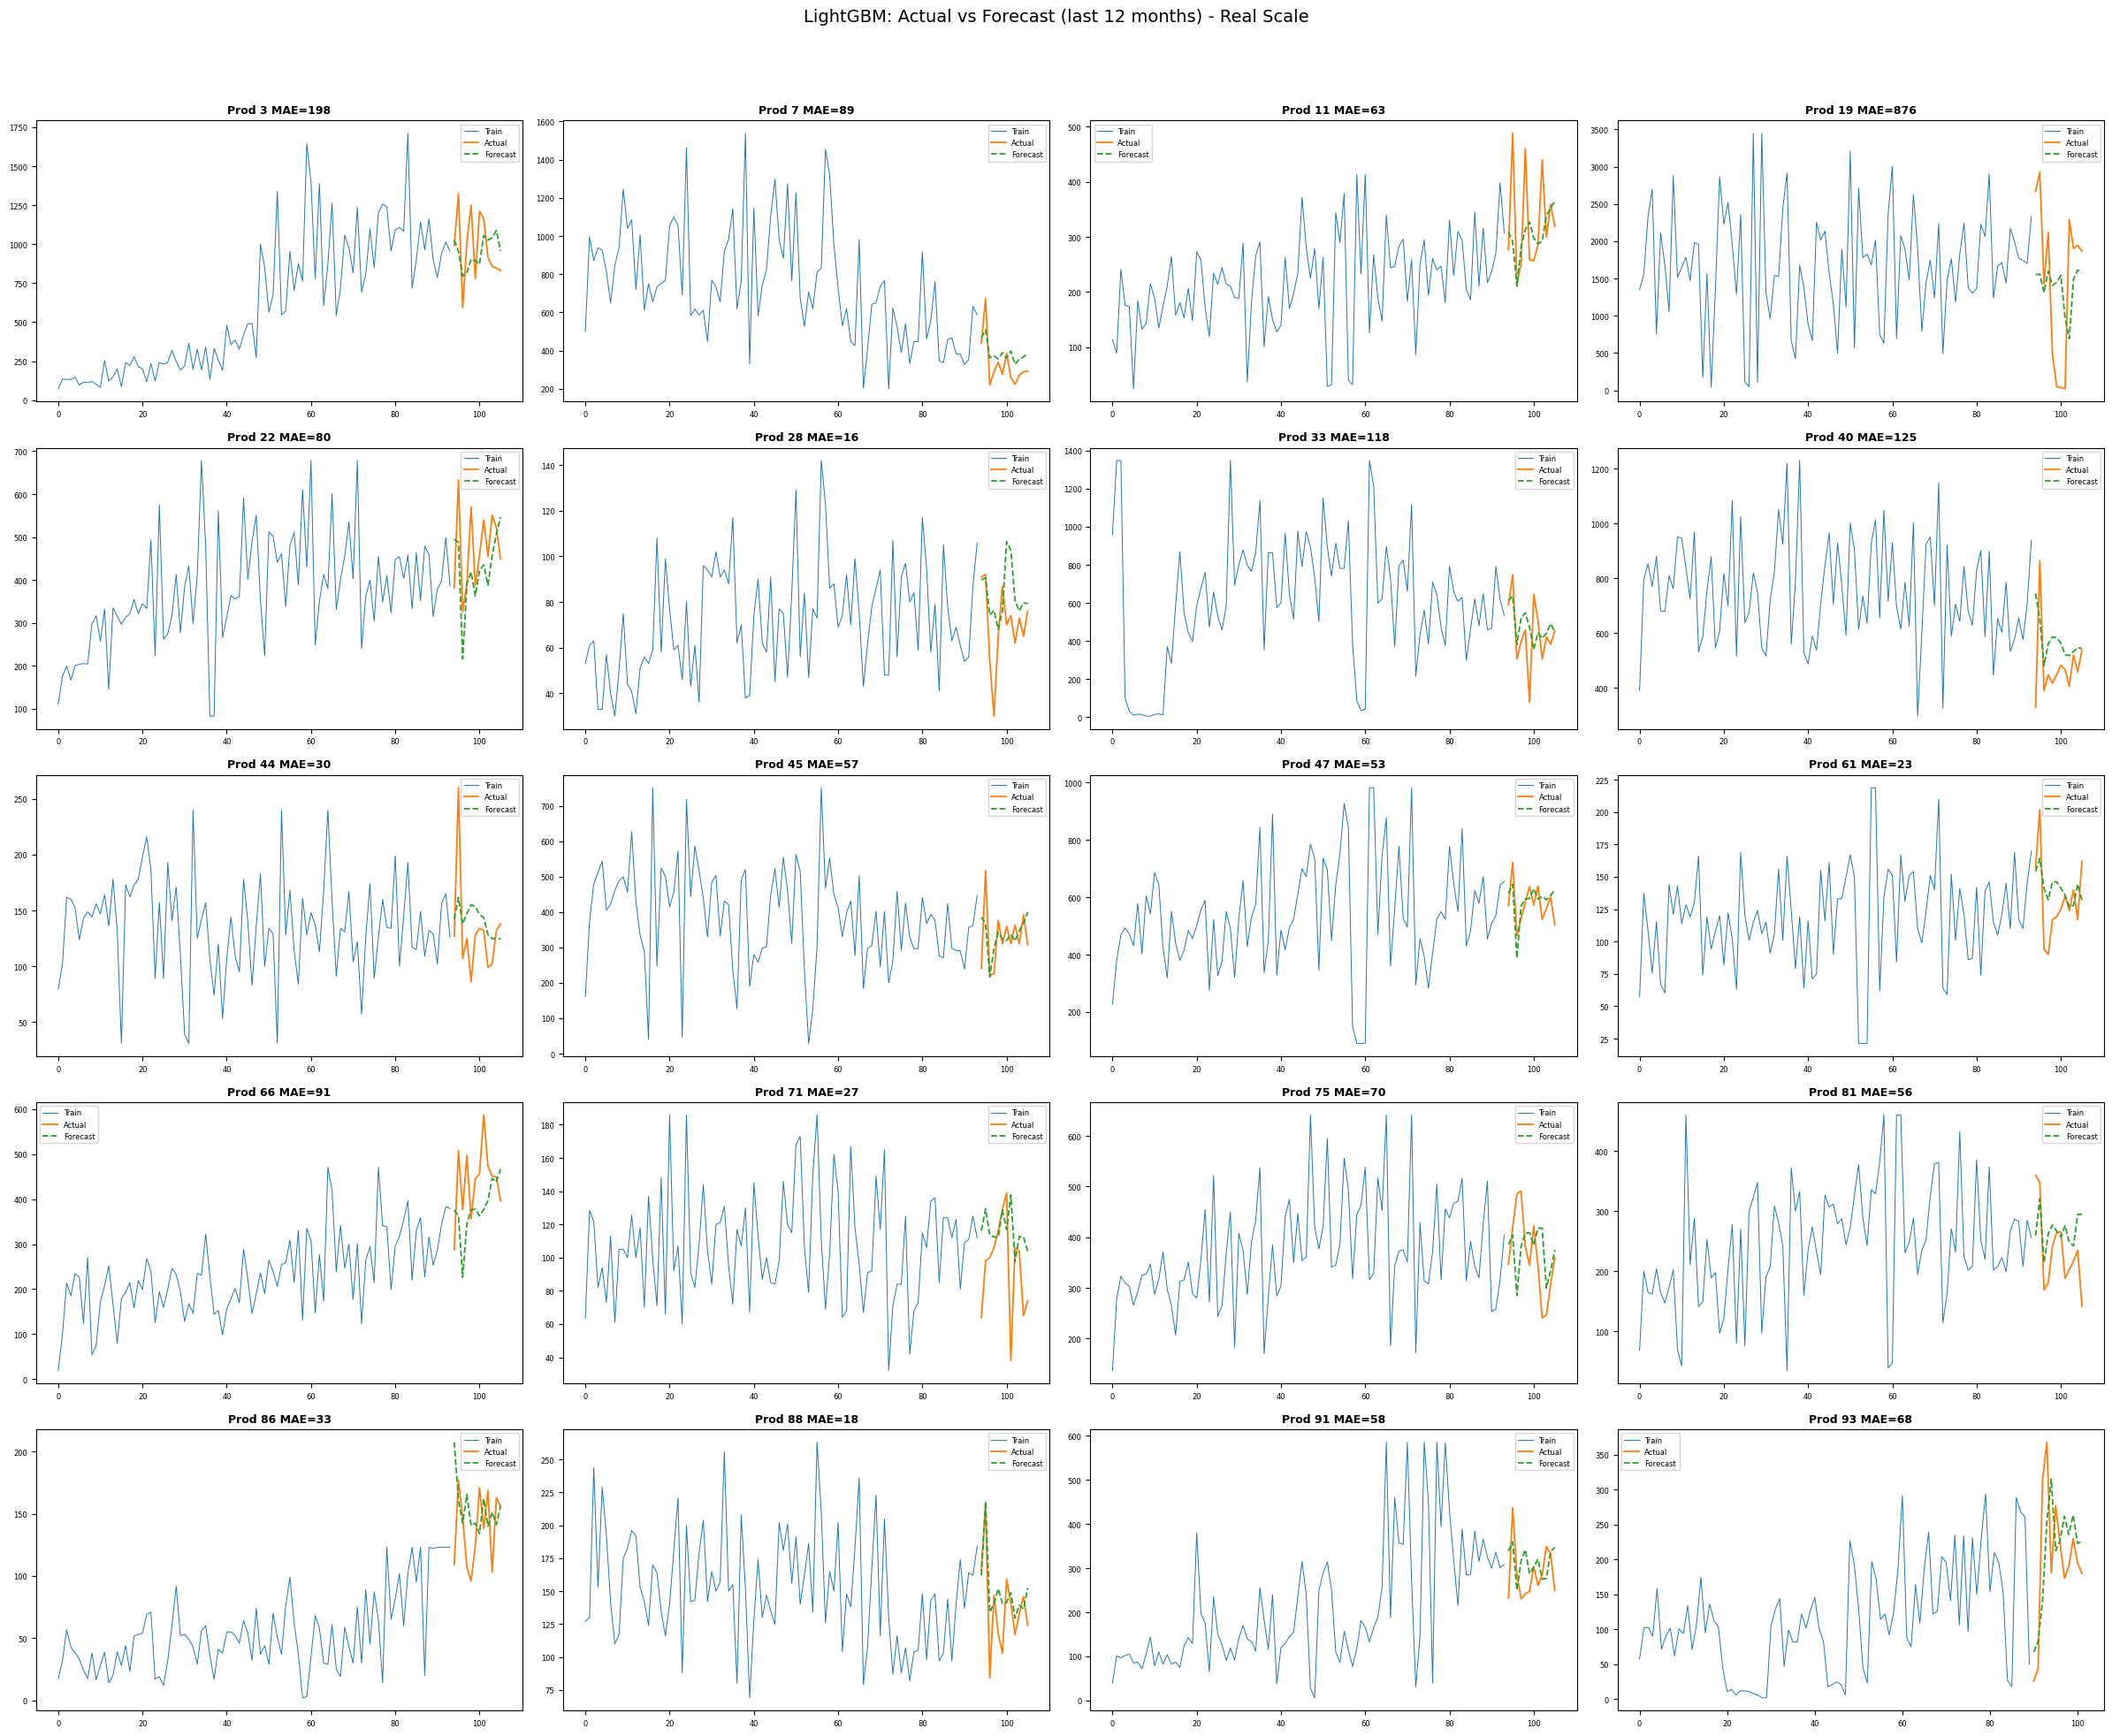


✓ All Actual vs Forecast plots generated and displayed.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(5, 4, figsize=(24, 20))
axes = axes.flatten()

if 'Predictions' not in df_test.columns:
    print("Warning: 'Predictions' column not found in df_test. Predicting now.")
    test_predictions = model.predict(X_test)
    df_test['Predictions'] = test_predictions

for i, pid in enumerate(product_ids):
    ax = axes[i]

    tr = df_train[df_train['ProductId'] == pid].copy()
    te = df_test[df_test['ProductId'] == pid].copy()

    if not te.empty:
        ax.plot(
            range(len(tr)),
            tr[TARGET].values,
            lw=0.7,
            label='Train'
        )

        ax.plot(
            range(len(tr), len(tr) + len(te)),
            te[TARGET].values,
            lw=1.3,
            label='Actual'
        )

        ax.plot(
            range(len(tr), len(tr) + len(te)),
            te['Predictions'].values,
            '--',
            lw=1.3,
            label='Forecast'
        )

        mae = mean_absolute_error(te[TARGET], te['Predictions'])

        ax.set_title(
            f'Prod {pid} MAE={mae:.0f}',
            fontsize=9,
            fontweight='bold'
        )

        ax.legend(fontsize=6)
    else:
        ax.set_title(f'Prod {pid} (No Test Data)', fontsize=9, fontweight='bold')
        ax.text(0.5, 0.5, 'No Test Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    ax.tick_params(labelsize=6)

plt.suptitle(
    'LightGBM: Actual vs Forecast (last 12 months) - Real Scale',
    fontsize=14,
    y=1.01
)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\n✓ All Actual vs Forecast plots generated and displayed.")